In [1]:
%run plotting_utils.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1 as ff1
import fastf1.plotting as ff1_plot
ff1_plot.setup_mpl(color_scheme='fastf1')
ff1.Cache.enable_cache('cache_dir')

from matplotlib import font_manager
from matplotlib.patches import Patch

In [2]:
monaco_race = ff1.get_session(2026, 'Monaco', 'R')
monaco_race.load()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


In [3]:
ANT_COLOR = ff1.plotting.get_driver_color('ANT', session=monaco_race)
RUS_COLOR = 'white'

req            INFO 	Using cached data for driver_info


---

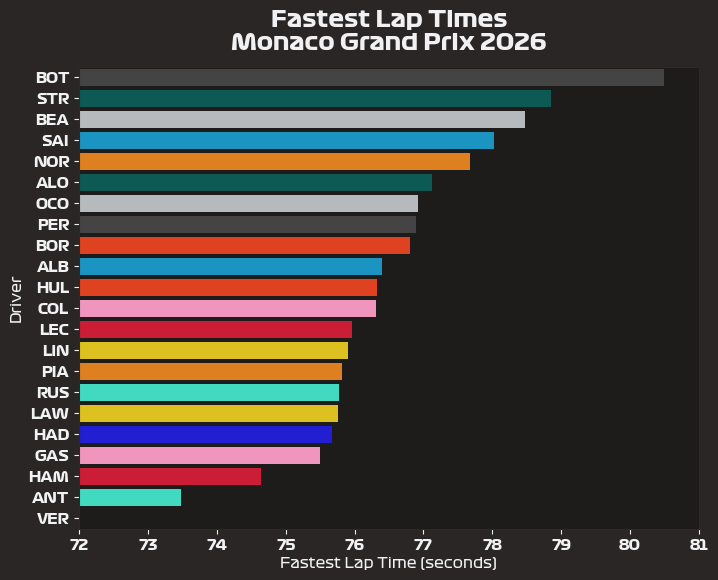

In [4]:
plot_fastest_lap_times(monaco_race, (72, 81))

As one may expect, the winner of the Monaco GP, Kimi Antonelli, held the fastest lap time (besides Max Verstappen who retired early in the race and unfortunately did not finish a full lap). He was so fast that he led the pack for all 78 laps!

His fellow driver at Mercedes and contender for WDC, George Russell, held the 6th fastest lap time and unfortunately did not score points in Monaco, partially to the fault of the multiple penalties he accrued. We'll analyze his telemetry in comparison to Antonelli to see what else occurred differently, and if it might be a car performance problem.

---

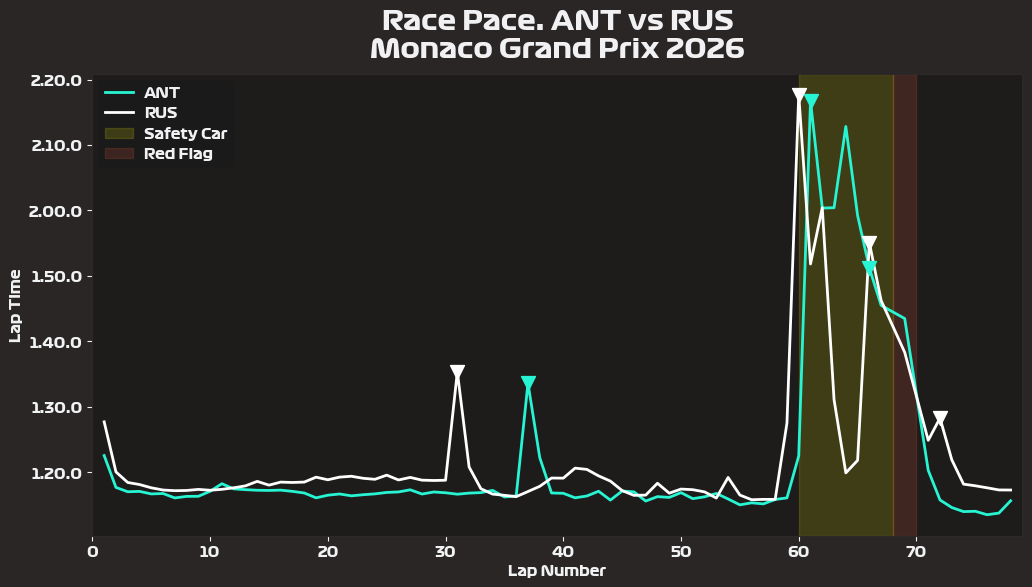

In [5]:
plot_race_pace(monaco_race, 'ANT', 'RUS', ANT_COLOR, RUS_COLOR, 
               regions=[(60, 68, 'Safety Car', 'yellow'), (68, 70, 'Red Flag', 'tomato')])

At the end of Lap 60, Stroll hit the barrier at Turn 19 due to locking up. This triggered a safety car for five laps, and all drivers were required to follow it through the pit lane. Antonelli and Russell eventually double stack their pit stop, but due to unclear communication between the engineers Russell did not serve his 5-second penalty given earlier for speeding in the pit lane. Antonelli remains in the lead.

It wasn't too long after the safety car ended that Leclerc hit the same barrier at Turn 19 on Lap 66. This led to another safety car and eventually a red flag on Lap 68, stopping the race to inspect the track at Turn 19. The race resumed on Lap 71. Because of this, lap time data is missing on Laps 67 and 69 and these points are interpolated on the graph.

---

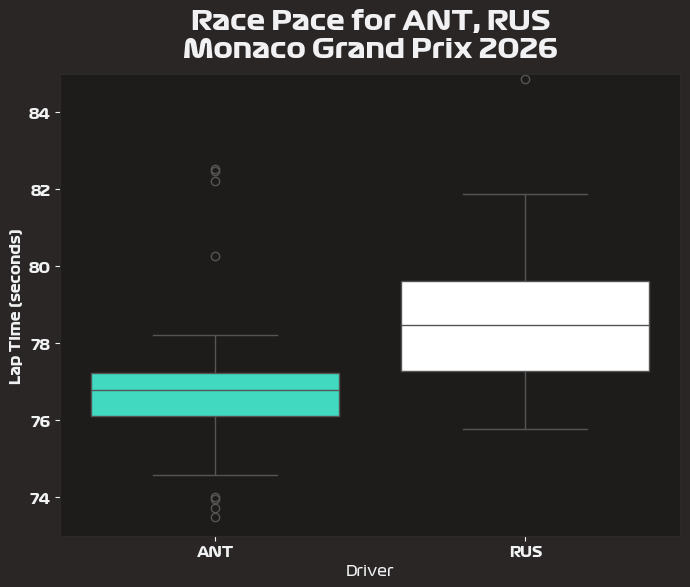

In [6]:
plot_race_pace_boxplot(monaco_race, ['ANT', 'RUS'], [ANT_COLOR, RUS_COLOR], ylim=(73,85))

This shows that 75% of Russell's laps were slower than the fastest 75% of Antonelli's laps.

---

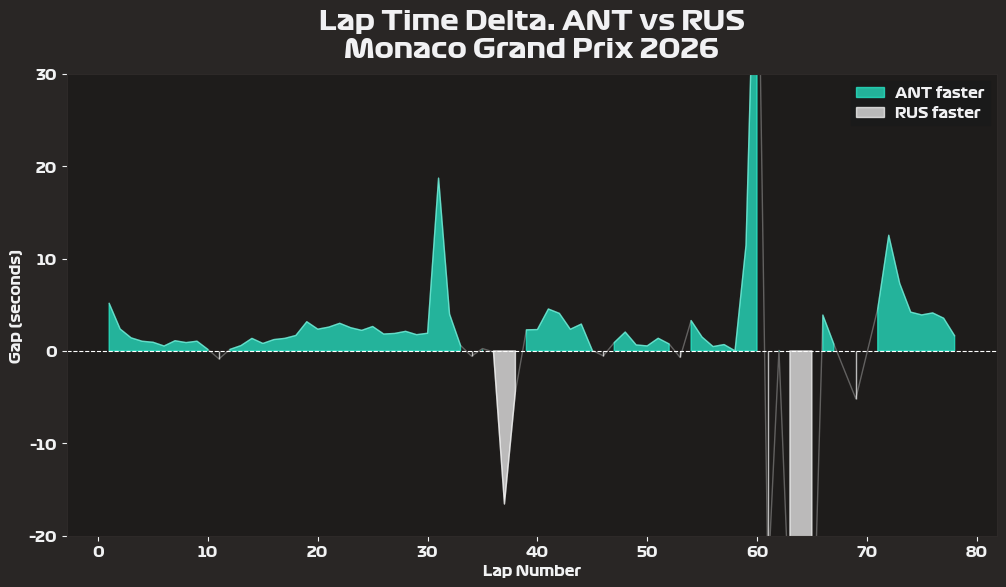

In [7]:
plot_lap_time_delta(monaco_race, 'ANT', 'RUS', ANT_COLOR, RUS_COLOR, ylim=(-20, 30))

For the majority of the race, Antonelli put in faster laps than Russell.

---

/Users/billtaing/formula1/venv/lib/python3.12/site-packages/fastf1/utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


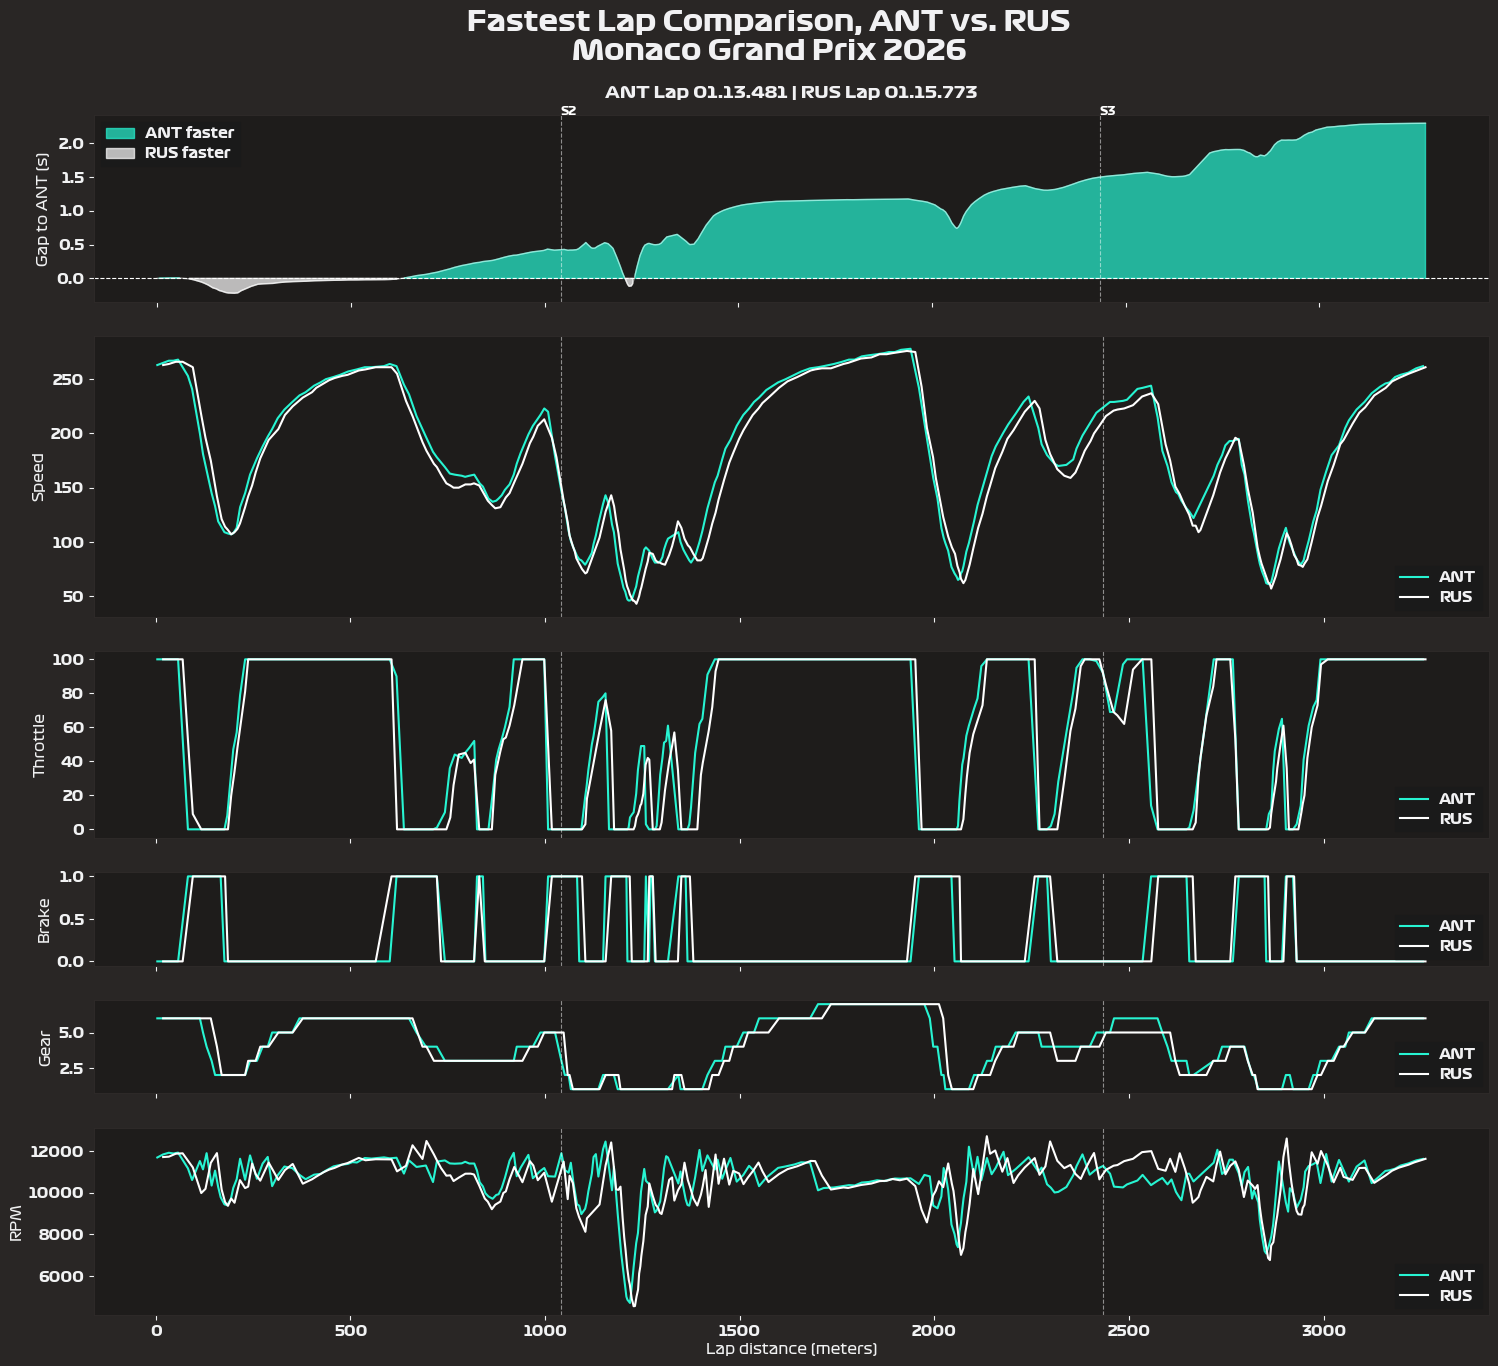

In [8]:
fastest_lap_comparison(monaco_race, 'ANT', 'RUS', ANT_COLOR, RUS_COLOR)

This telemetry chart compares Antonelli's and Russell's fastest laps. 

At the beginning in S1, Russell seems to have the advantage on Antonelli, but loses it 600 meters in. We can see this is because he brakes a bit earlier than Antonelli going into the turn.

In S2 (the tunnel), Antonelli becomes consistently faster and the gap grows steadily until the end of S3. This suggests it's an overall setup or confidence difference rather than one point in the lap where Russell faulted.

---

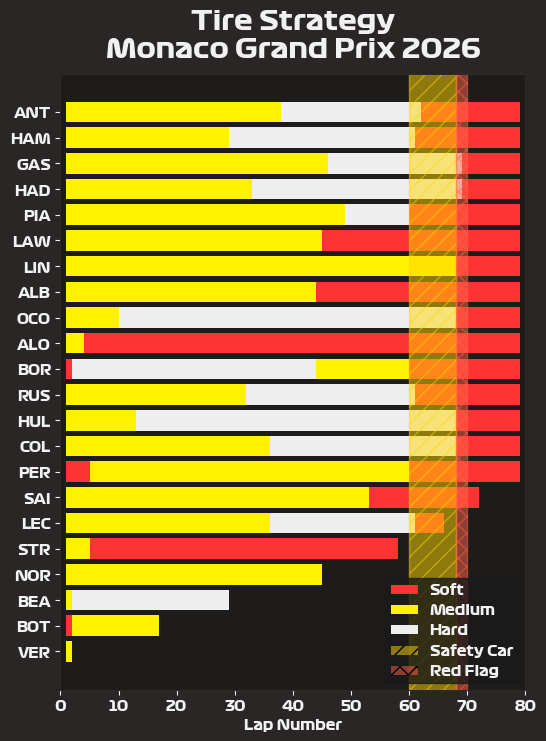

In [9]:
plot_tire_strategy(monaco_race, 
                   regions=[(60, 68, 'Safety Car', 'gold', '//'), 
                            (68, 70, 'Red Flag', 'tomato', 'xx')])

The track at Monaco means low degradation, so the softest tires are preferred for maximum grip. However, it's notoriously difficult to overtake at Monaco due to the track width and tight corners, so most drivers started the race on mediums in order to keep their first stint going on as long as possible and maintain track position. Additionally, we see that most teams opted for a one-stop strategy, switching to hards for the second stint for more durability.

But there came the wild card of the incidents at Turn 19 causing two safety cars and red flag. During the safety car period, a few drivers switched to softs. After the red flag restart, all remaining drivers had soft tires in order to maximize grip with only a few laps remaining until the finish line.

---